In [ ]:
# CELL 1 — Load once (Colab upload) + common setup (Level 1)
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Upload once
uploaded = files.upload()  # upload fusion_training_table_2020_normalized.csv
fname = next(iter(uploaded))
print("Loaded:", fname)

df = pd.read_csv(io.BytesIO(uploaded[fname]))
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# Level 1 feature set
TARGET = "SM_ISMN_daily"
FEATURES_L1 = ["SM_SMAP", "SM_SMAP_lag1"]

# Validate columns
missing = [c for c in [TARGET] + FEATURES_L1 if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Clean once for L1
data_l1 = df[FEATURES_L1 + [TARGET]].copy().dropna()
X = data_l1[FEATURES_L1]
y = data_l1[TARGET]

# Fix split once (shared by all models)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def pearson_corr(a, b):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    if a.size < 2:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def eval_and_plot(model_name, features_used, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    bias = float(np.mean(y_pred - np.asarray(y_true)))
    pearson = pearson_corr(y_true, y_pred)

    print(f"\n=== {model_name} — LEVEL 1 ===")
    print("Features used:", features_used)
    print(f"R2      : {r2:.4f}")
    print(f"RMSE    : {rmse:.4f}")
    print(f"MAE     : {mae:.4f}")
    print(f"Bias    : {bias:.4f}")
    print(f"Pearson : {pearson:.4f}")

    # Predicted vs Observed plot
    plt.figure()
    plt.scatter(y_true, y_pred)
    mn = float(min(np.min(y_true), np.min(y_pred)))
    mx = float(max(np.max(y_true), np.max(y_pred)))
    plt.plot([mn, mx], [mn, mx])
    plt.xlabel("Observed (ISMN) Soil Moisture")
    plt.ylabel("Predicted Soil Moisture")
    plt.title(f"{model_name} — L1 Predicted vs Observed")
    plt.show()

Saving fusion_training_table_2020_normalized.csv to fusion_training_table_2020_normalized.csv
Loaded: fusion_training_table_2020_normalized.csv
Shape: (354, 14)
Columns: ['date', 'SM_ISMN_daily', 'SM_SMAP', 'SM_SMAP_lag1', 'NDMI_S2', 'NDVI_S2', 'NDVI_7day', 'NDMI_7day', 'P_ERA5_daily', 'T2M_ERA5_daily', 'P_lag1', 'P_lag2', 'P_lag3', 'P_7day']



=== Random Forest — LEVEL 1 ===
Features used: ['SM_SMAP', 'SM_SMAP_lag1']
R2      : 0.5362
RMSE    : 0.1842
MAE     : 0.1386
Bias    : 0.0074
Pearson : 0.7377


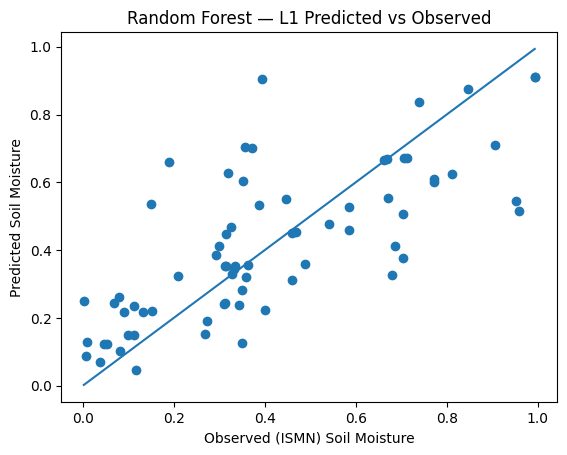

In [ ]:
# CELL 2 — Random Forest (Level 1)
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

eval_and_plot("Random Forest", FEATURES_L1, y_test, pred_rf)


=== XGBoost — LEVEL 1 ===
Features used: ['SM_SMAP', 'SM_SMAP_lag1']
R2      : 0.5969
RMSE    : 0.1717
MAE     : 0.1235
Bias    : 0.0104
Pearson : 0.7742


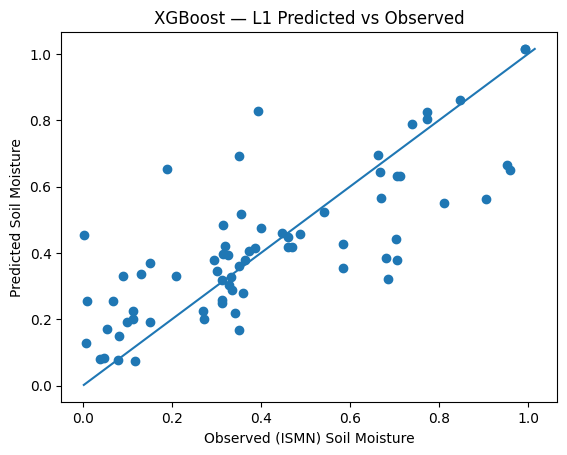

In [ ]:
# CELL 3 — XGBoost (Level 1)
# If xgboost import fails in your runtime, run:
# !pip -q install xgboost
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

eval_and_plot("XGBoost", FEATURES_L1, y_test, pred_xgb)


=== Ensemble (RF + XGB avg) — LEVEL 1 ===
Features used: ['SM_SMAP', 'SM_SMAP_lag1']
R2      : 0.6002
RMSE    : 0.1710
MAE     : 0.1276
Bias    : 0.0089
Pearson : 0.7756


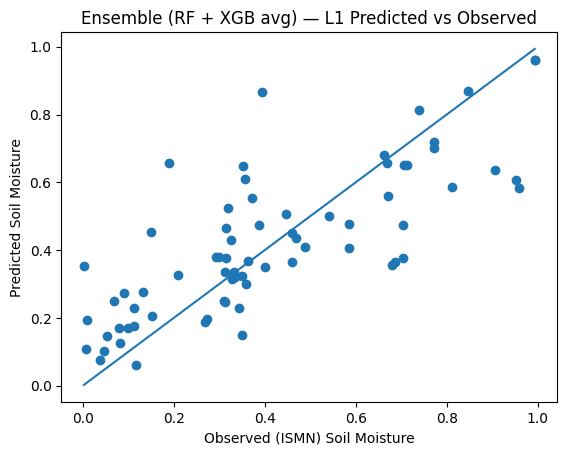

In [ ]:
# CELL 4 — Ensemble (Average of RF + XGB) (Level 1)
# Uses pred_rf and pred_xgb from previous cells
pred_ens = 0.5 * (pred_rf + pred_xgb)

eval_and_plot("Ensemble (RF + XGB avg)", FEATURES_L1, y_test, pred_ens)

In [ ]:
# CELL 1 — Level 2 setup (uses df already loaded in your notebook)
# Do NOT re-upload. Run this once for Level 2.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

TARGET = "SM_ISMN_daily"
FEATURES_L2 = ["SM_SMAP", "SM_SMAP_lag1", "NDVI_S2", "NDMI_S2"]

missing = [c for c in [TARGET] + FEATURES_L2 if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

data_l2 = df[FEATURES_L2 + [TARGET]].copy().dropna()
X2 = data_l2[FEATURES_L2]
y2 = data_l2[TARGET]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

def pearson_corr(a, b):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    if a.size < 2:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def eval_and_plot(model_name, features_used, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    bias = float(np.mean(y_pred - np.asarray(y_true)))
    pearson = pearson_corr(y_true, y_pred)

    print(f"\n=== {model_name} — LEVEL 2 ===")
    print("Features used:", features_used)
    print(f"R2      : {r2:.4f}")
    print(f"RMSE    : {rmse:.4f}")
    print(f"MAE     : {mae:.4f}")
    print(f"Bias    : {bias:.4f}")
    print(f"Pearson : {pearson:.4f}")

    plt.figure()
    plt.scatter(y_true, y_pred)
    mn = float(min(np.min(y_true), np.min(y_pred)))
    mx = float(max(np.max(y_true), np.max(y_pred)))
    plt.plot([mn, mx], [mn, mx])
    plt.xlabel("Observed (ISMN) Soil Moisture")
    plt.ylabel("Predicted Soil Moisture")
    plt.title(f"{model_name} — L2 Predicted vs Observed")
    plt.show()

print("Level 2 rows used:", len(data_l2))

Level 2 rows used: 354



=== Random Forest — LEVEL 2 ===
Features used: ['SM_SMAP', 'SM_SMAP_lag1', 'NDVI_S2', 'NDMI_S2']
R2      : 0.8109
RMSE    : 0.1176
MAE     : 0.0778
Bias    : -0.0037
Pearson : 0.9008


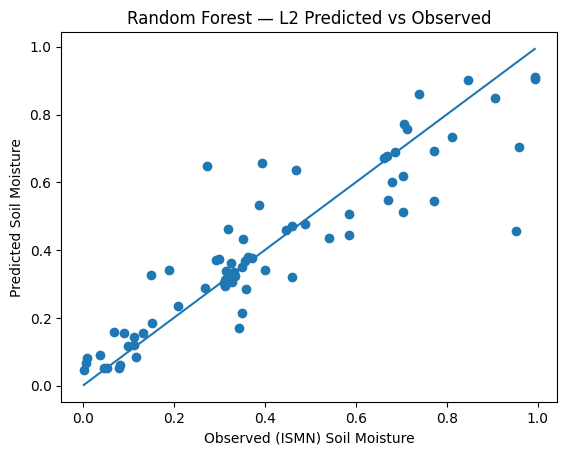

In [ ]:
# CELL 2 — Random Forest (Level 2)
from sklearn.ensemble import RandomForestRegressor

rf2 = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf2.fit(X2_train, y2_train)
pred_rf2 = rf2.predict(X2_test)

eval_and_plot("Random Forest", FEATURES_L2, y2_test, pred_rf2)


=== XGBoost — LEVEL 2 ===
Features used: ['SM_SMAP', 'SM_SMAP_lag1', 'NDVI_S2', 'NDMI_S2']
R2      : 0.8437
RMSE    : 0.1069
MAE     : 0.0748
Bias    : 0.0014
Pearson : 0.9186


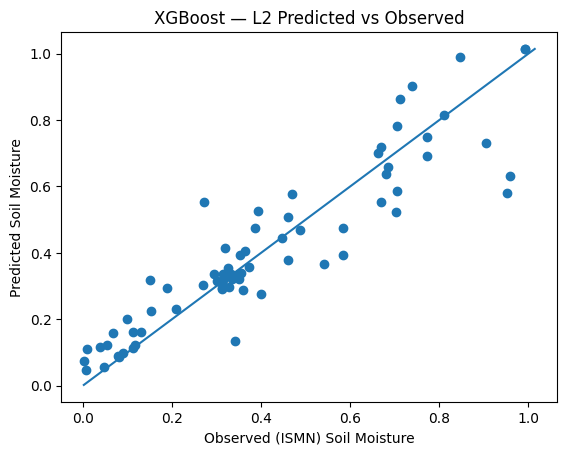

In [ ]:
# CELL 3 — XGBoost (Level 2)
# If xgboost import fails in your runtime, run:
# !pip -q install xgboost
from xgboost import XGBRegressor

xgb2 = XGBRegressor(
    n_estimators=700,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

xgb2.fit(X2_train, y2_train)
pred_xgb2 = xgb2.predict(X2_test)

eval_and_plot("XGBoost", FEATURES_L2, y2_test, pred_xgb2)


=== Ensemble (RF + XGB avg) — LEVEL 2 ===
Features used: ['SM_SMAP', 'SM_SMAP_lag1', 'NDVI_S2', 'NDMI_S2']
R2      : 0.8376
RMSE    : 0.1090
MAE     : 0.0750
Bias    : -0.0011
Pearson : 0.9156


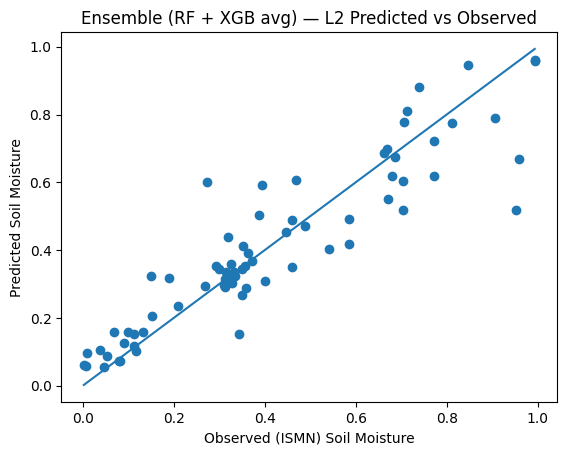

In [ ]:
# CELL 4 — Ensemble (Average of RF + XGB) (Level 2)
pred_ens2 = 0.5 * (pred_rf2 + pred_xgb2)

eval_and_plot("Ensemble (RF + XGB avg)", FEATURES_L2, y2_test, pred_ens2)

In [ ]:
# CELL 1 — Level 3 setup (uses df already loaded earlier)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

TARGET = "SM_ISMN_daily"

FEATURES_L3 = [
    "SM_SMAP",
    "SM_SMAP_lag1",
    "NDVI_S2",
    "NDMI_S2",
    "NDVI_7day",
    "NDMI_7day"
]

missing = [c for c in [TARGET] + FEATURES_L3 if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

data_l3 = df[FEATURES_L3 + [TARGET]].copy().dropna()

X3 = data_l3[FEATURES_L3]
y3 = data_l3[TARGET]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

def pearson_corr(a, b):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    return float(np.corrcoef(a, b)[0,1])

def eval_and_plot(model_name, features_used, y_true, y_pred):

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    pearson = pearson_corr(y_true, y_pred)

    print(f"\n=== {model_name} — LEVEL 3 ===")
    print("Features used:", features_used)

    print("R²      :", round(r2,4))
    print("RMSE    :", round(rmse,4))
    print("MAE     :", round(mae,4))
    print("Bias    :", round(bias,4))
    print("Pearson :", round(pearson,4))

    # Predicted vs Observed plot
    plt.figure()
    plt.scatter(y_true, y_pred)

    mn = min(min(y_true), min(y_pred))
    mx = max(max(y_true), max(y_pred))

    plt.plot([mn, mx], [mn, mx])
    plt.xlabel("Observed Soil Moisture (ISMN)")
    plt.ylabel("Predicted Soil Moisture")
    plt.title(f"{model_name} — L3 Predicted vs Observed")
    plt.show()

print("Rows used for Level 3:", len(data_l3))

Rows used for Level 3: 354



=== Random Forest — LEVEL 3 ===
Features used: ['SM_SMAP', 'SM_SMAP_lag1', 'NDVI_S2', 'NDMI_S2', 'NDVI_7day', 'NDMI_7day']
R²      : 0.9193
RMSE    : 0.0768
MAE     : 0.0542
Bias    : -0.0065
Pearson : 0.9611


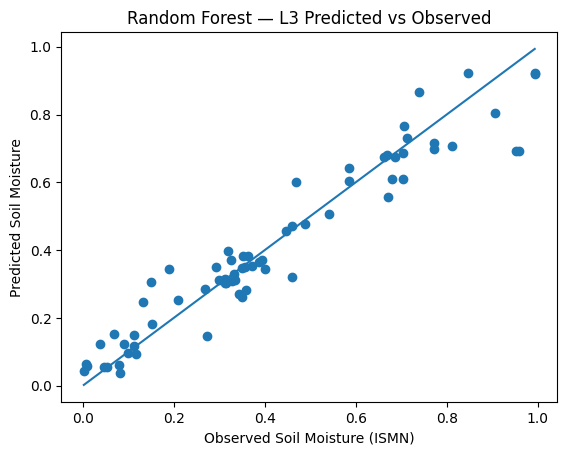

In [ ]:
# CELL 2 — Random Forest (Level 3)

from sklearn.ensemble import RandomForestRegressor

rf3 = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf3.fit(X3_train, y3_train)

pred_rf3 = rf3.predict(X3_test)

eval_and_plot("Random Forest", FEATURES_L3, y3_test, pred_rf3)


=== XGBoost — LEVEL 3 ===
Features used: ['SM_SMAP', 'SM_SMAP_lag1', 'NDVI_S2', 'NDMI_S2', 'NDVI_7day', 'NDMI_7day']
R²      : 0.9058
RMSE    : 0.083
MAE     : 0.0548
Bias    : 0.003
Pearson : 0.9521


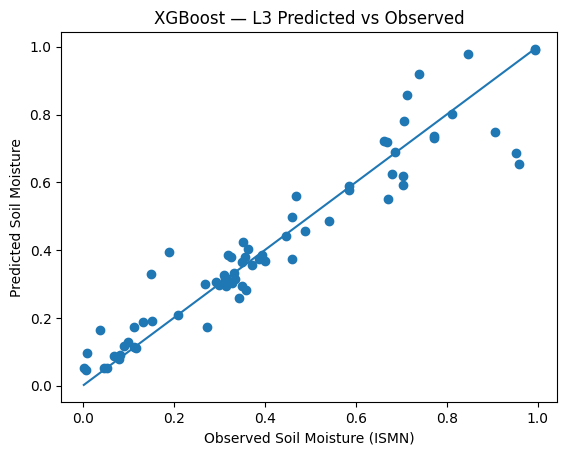

In [ ]:
# CELL 3 — XGBoost (Level 3)

# If not installed:
# !pip install xgboost

from xgboost import XGBRegressor

xgb3 = XGBRegressor(
    n_estimators=700,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1
)

xgb3.fit(X3_train, y3_train)

pred_xgb3 = xgb3.predict(X3_test)

eval_and_plot("XGBoost", FEATURES_L3, y3_test, pred_xgb3)


=== Ensemble (RF + XGB) — LEVEL 3 ===
Features used: ['SM_SMAP', 'SM_SMAP_lag1', 'NDVI_S2', 'NDMI_S2', 'NDVI_7day', 'NDMI_7day']
R²      : 0.9173
RMSE    : 0.0778
MAE     : 0.0539
Bias    : -0.0018
Pearson : 0.9589


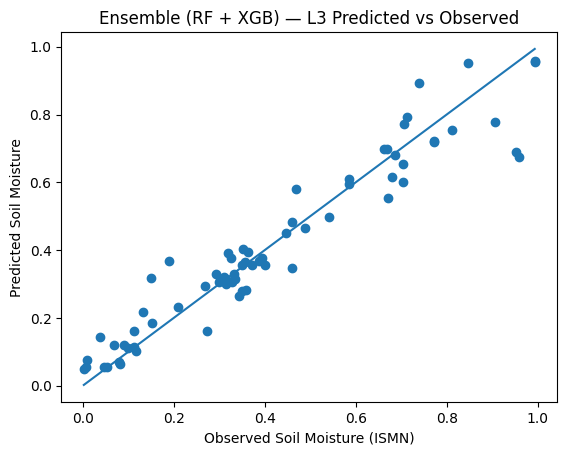

In [ ]:
# CELL 4 — Ensemble (RF + XGB Average) — Level 3

pred_ensemble3 = (pred_rf3 + pred_xgb3) / 2

eval_and_plot("Ensemble (RF + XGB)", FEATURES_L3, y3_test, pred_ensemble3)

In [ ]:
# CELL 1 — Level 4 setup (uses df already loaded earlier)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

TARGET = "SM_ISMN_daily"

FEATURES_L4 = [
    "SM_SMAP",
    "SM_SMAP_lag1",
    "NDVI_S2",
    "NDMI_S2",
    "NDVI_7day",
    "NDMI_7day",
    "P_ERA5_daily",
    "T2M_ERA5_daily"
]

missing = [c for c in [TARGET] + FEATURES_L4 if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

data_l4 = df[FEATURES_L4 + [TARGET]].copy().dropna()

X4 = data_l4[FEATURES_L4]
y4 = data_l4[TARGET]

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4, y4, test_size=0.2, random_state=42
)

def pearson_corr(a, b):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    if a.size < 2:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def eval_and_plot(model_name, features_used, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    bias = float(np.mean(y_pred - np.asarray(y_true)))
    pearson = pearson_corr(y_true, y_pred)

    print(f"\n=== {model_name} — LEVEL 4 ===")
    print("Features used:", features_used)
    print(f"R2      : {r2:.4f}")
    print(f"RMSE    : {rmse:.4f}")
    print(f"MAE     : {mae:.4f}")
    print(f"Bias    : {bias:.4f}")
    print(f"Pearson : {pearson:.4f}")

    plt.figure()
    plt.scatter(y_true, y_pred)
    mn = float(min(np.min(y_true), np.min(y_pred)))
    mx = float(max(np.max(y_true), np.max(y_pred)))
    plt.plot([mn, mx], [mn, mx])
    plt.xlabel("Observed (ISMN) Soil Moisture")
    plt.ylabel("Predicted Soil Moisture")
    plt.title(f"{model_name} — L4 Predicted vs Observed")
    plt.show()

print("Rows used for Level 4:", len(data_l4))

Rows used for Level 4: 354



=== Random Forest — LEVEL 4 ===
Features used: ['SM_SMAP', 'SM_SMAP_lag1', 'NDVI_S2', 'NDMI_S2', 'NDVI_7day', 'NDMI_7day', 'P_ERA5_daily', 'T2M_ERA5_daily']
R2      : 0.9212
RMSE    : 0.0759
MAE     : 0.0529
Bias    : -0.0101
Pearson : 0.9645


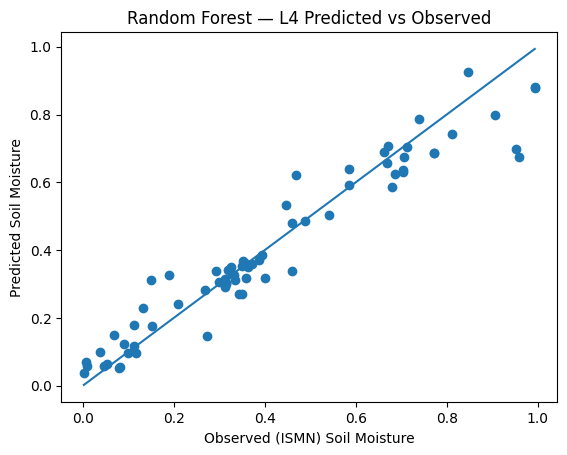

In [ ]:
# CELL 2 — Random Forest (Level 4)

from sklearn.ensemble import RandomForestRegressor

rf4 = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf4.fit(X4_train, y4_train)
pred_rf4 = rf4.predict(X4_test)

eval_and_plot("Random Forest", FEATURES_L4, y4_test, pred_rf4)


=== XGBoost — LEVEL 4 ===
Features used: ['SM_SMAP', 'SM_SMAP_lag1', 'NDVI_S2', 'NDMI_S2', 'NDVI_7day', 'NDMI_7day', 'P_ERA5_daily', 'T2M_ERA5_daily']
R2      : 0.9175
RMSE    : 0.0777
MAE     : 0.0545
Bias    : -0.0025
Pearson : 0.9601


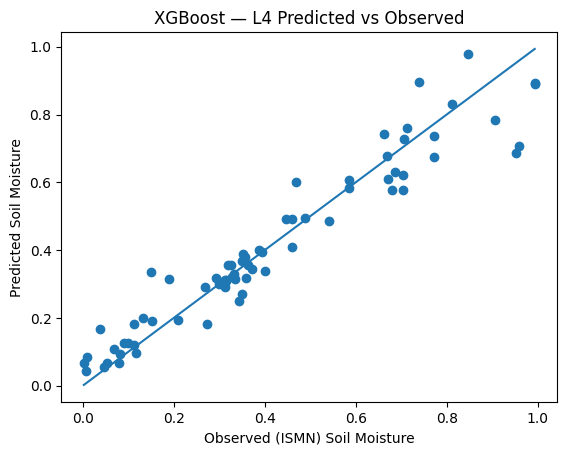

In [ ]:
# CELL 3 — XGBoost (Level 4)

# If not installed:
# !pip -q install xgboost
from xgboost import XGBRegressor

xgb4 = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

xgb4.fit(X4_train, y4_train)
pred_xgb4 = xgb4.predict(X4_test)

eval_and_plot("XGBoost", FEATURES_L4, y4_test, pred_xgb4)


=== Ensemble (RF + XGB avg) — LEVEL 4 ===
Features used: ['SM_SMAP', 'SM_SMAP_lag1', 'NDVI_S2', 'NDMI_S2', 'NDVI_7day', 'NDMI_7day', 'P_ERA5_daily', 'T2M_ERA5_daily']
R2      : 0.9232
RMSE    : 0.0750
MAE     : 0.0516
Bias    : -0.0063
Pearson : 0.9644


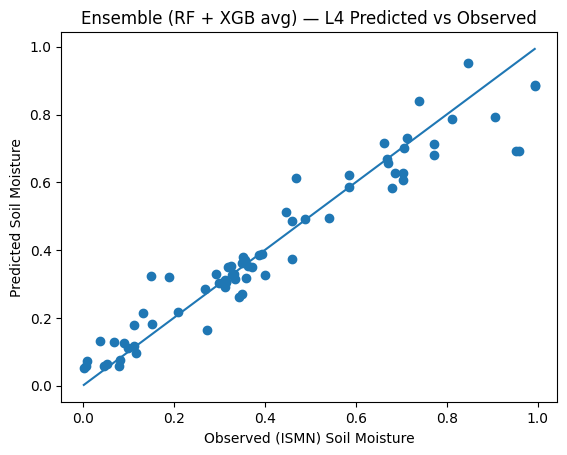

In [ ]:
# CELL 4 — Ensemble (RF + XGB Average) — Level 4

pred_ens4 = 0.5 * (pred_rf4 + pred_xgb4)

eval_and_plot("Ensemble (RF + XGB avg)", FEATURES_L4, y4_test, pred_ens4)

In [ ]:
# CELL 1 — Level 5 setup (uses df already loaded earlier)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

TARGET = "SM_ISMN_daily"

FEATURES_L5 = [
    "SM_SMAP",
    "SM_SMAP_lag1",
    "NDVI_S2",
    "NDMI_S2",
    "NDVI_7day",
    "NDMI_7day",
    "P_ERA5_daily",
    "T2M_ERA5_daily",
    "P_lag1",
    "P_lag2",
    "P_lag3",
    "P_7day"
]

missing = [c for c in [TARGET] + FEATURES_L5 if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

data_l5 = df[FEATURES_L5 + [TARGET]].copy().dropna()

X5 = data_l5[FEATURES_L5]
y5 = data_l5[TARGET]

X5_train, X5_test, y5_train, y5_test = train_test_split(
    X5, y5, test_size=0.2, random_state=42
)

def pearson_corr(a, b):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    if a.size < 2:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def eval_and_plot(model_name, features_used, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    bias = float(np.mean(y_pred - np.asarray(y_true)))
    pearson = pearson_corr(y_true, y_pred)

    print(f"\n=== {model_name} — LEVEL 5 ===")
    print("Features used:", features_used)
    print(f"R2      : {r2:.4f}")
    print(f"RMSE    : {rmse:.4f}")
    print(f"MAE     : {mae:.4f}")
    print(f"Bias    : {bias:.4f}")
    print(f"Pearson : {pearson:.4f}")

    plt.figure()
    plt.scatter(y_true, y_pred)
    mn = float(min(np.min(y_true), np.min(y_pred)))
    mx = float(max(np.max(y_true), np.max(y_pred)))
    plt.plot([mn, mx], [mn, mx])
    plt.xlabel("Observed (ISMN) Soil Moisture")
    plt.ylabel("Predicted Soil Moisture")
    plt.title(f"{model_name} — L5 Predicted vs Observed")
    plt.show()

print("Rows used for Level 5:", len(data_l5))

Rows used for Level 5: 354



=== Random Forest — LEVEL 5 ===
Features used: ['SM_SMAP', 'SM_SMAP_lag1', 'NDVI_S2', 'NDMI_S2', 'NDVI_7day', 'NDMI_7day', 'P_ERA5_daily', 'T2M_ERA5_daily', 'P_lag1', 'P_lag2', 'P_lag3', 'P_7day']
R2      : 0.9306
RMSE    : 0.0713
MAE     : 0.0516
Bias    : -0.0085
Pearson : 0.9673


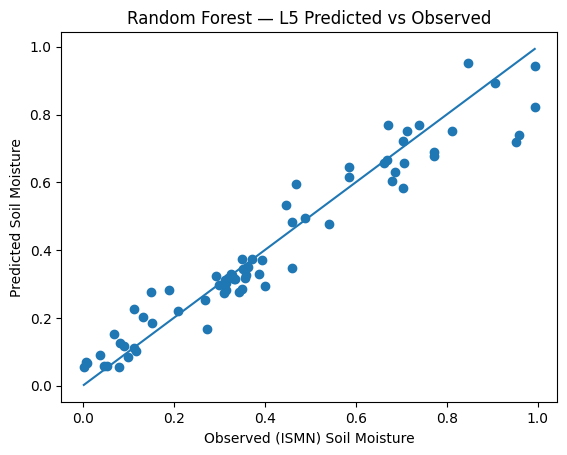

In [ ]:
# CELL 2 — Random Forest (Level 5)

from sklearn.ensemble import RandomForestRegressor

rf5 = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf5.fit(X5_train, y5_train)
pred_rf5 = rf5.predict(X5_test)

eval_and_plot("Random Forest", FEATURES_L5, y5_test, pred_rf5)


=== XGBoost — LEVEL 5 ===
Features used: ['SM_SMAP', 'SM_SMAP_lag1', 'NDVI_S2', 'NDMI_S2', 'NDVI_7day', 'NDMI_7day', 'P_ERA5_daily', 'T2M_ERA5_daily', 'P_lag1', 'P_lag2', 'P_lag3', 'P_7day']
R2      : 0.9209
RMSE    : 0.0761
MAE     : 0.0559
Bias    : -0.0006
Pearson : 0.9613


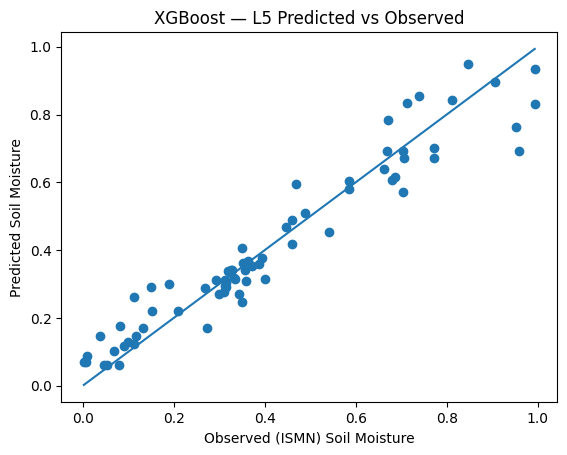

In [ ]:
# CELL 3 — XGBoost (Level 5)

# If not installed:
# !pip -q install xgboost
from xgboost import XGBRegressor

xgb5 = XGBRegressor(
    n_estimators=900,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

xgb5.fit(X5_train, y5_train)
pred_xgb5 = xgb5.predict(X5_test)

eval_and_plot("XGBoost", FEATURES_L5, y5_test, pred_xgb5)


=== Ensemble (RF + XGB avg) — LEVEL 5 ===
Features used: ['SM_SMAP', 'SM_SMAP_lag1', 'NDVI_S2', 'NDMI_S2', 'NDVI_7day', 'NDMI_7day', 'P_ERA5_daily', 'T2M_ERA5_daily', 'P_lag1', 'P_lag2', 'P_lag3', 'P_7day']
R2      : 0.9290
RMSE    : 0.0720
MAE     : 0.0522
Bias    : -0.0046
Pearson : 0.9661


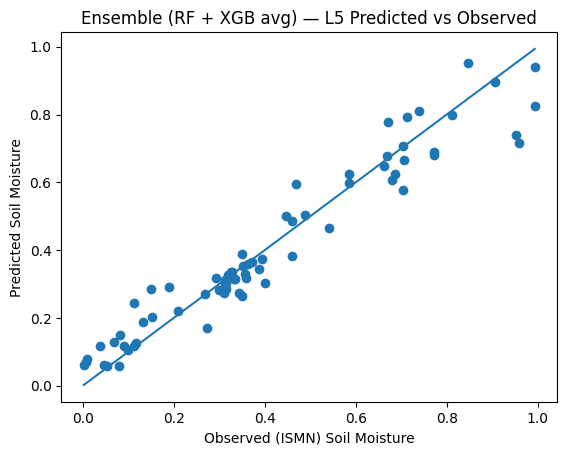

In [ ]:
# CELL 4 — Ensemble (RF + XGB Average) — Level 5

pred_ens5 = 0.5 * (pred_rf5 + pred_xgb5)

eval_and_plot("Ensemble (RF + XGB avg)", FEATURES_L5, y5_test, pred_ens5)